In [1]:
#import required classes and packages
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import svm
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading and displaying QWS dataset
dataset = pd.read_csv("Dataset/qws1.txt")
dataset

,Response_Time,Availability,Throughput,Successability,Reliability,Compliance,Best_Practices,Latency,Documentation,WsRF,Class,Service_Name,WSDL_Address
0,45.00,83,27.2,50,97.4,89,91,43.00,58,100,1,DictionaryService,http://www.mindswap.org/2002/services/Dictiona...
1,71.75,100,14.6,88,85.5,78,80,64.42,86,93,1,MyService,http://mydispatch.com/myservice.asmx?wsdl
2,117.00,100,23.4,83,88.0,100,87,111.00,59,90,1,aba,http://www.quentinsagerconsulting.com/wsdl/aba...
3,70.00,100,5.4,83,79.3,100,75,63.00,91,90,1,AlexaWebSearch,http://wsearch.amazonaws.com/doc/2007-03-15/We...
4,105.20,100,18.2,80,92.2,78,84,104.60,91,90,1,ErrorMailer,http://www.errormail.net/EM/ErrorMailer.asmx?wsdl
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,274.50,37,1.0,18,24.8,89,69,257.50,6,38,4,BINDService,http://seqhound.blueprint.org/wsdl/bind.wsdl
360,502.00,24,3.4,9,21.8,78,85,499.28,12,35,4,sss_spreadshop_servicesService,http://www.spreadshirt.net/services.php?wsdl
361,256.31,14,1.0,10,13.0,100,75,237.62,1,34,4,BFServiceV2,https://api.betfair.com/betex-api-public-ws/v2...
362,6962.85,28,0.5,21,30.0,78,69,6915.08,5,32,4,SKOSThesaurusService,http://nbii-thesaurus.ornl.gov/ws/services/SKO...


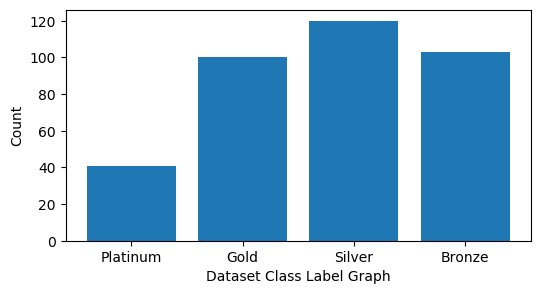

In [3]:
#visualizing class labels count found in full dataset
labels, count = np.unique(dataset['Class'], return_counts = True)
labels = ['Platinum', 'Gold', 'Silver', 'Bronze']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (6, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

In [4]:
#dataset preprocessing techniques like removing missing values, non-numeric values and then shuffling dataset
dataset.drop(['Service_Name', 'WSDL_Address'], axis = 1,inplace=True)
dataset.fillna(0, inplace = True)#replace missing values with 0
dataset = dataset.values
X = dataset[:,0:dataset.shape[1]-1]
Y = dataset[:,dataset.shape[1]-1]
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle dataset to manage all classes in train and test
X = X[indices]
Y = Y[indices]
print("Dataset Processing Completed")

Dataset Processing Completed


In [5]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Train & Test Split")
print("80% images used to train algorithms : "+str(X_train.shape[0]))
print("20% image used to train algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split
80% images used to train algorithms : 291
20% image used to train algorithms : 73


In [6]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [7]:
#function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    
    conf_matrix = confusion_matrix(y_test, predict) 
    plt.figure(figsize =(6, 3)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.xticks(rotation=90)
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()    

Decision Tree Accuracy  :  43.83561643835616
Decision Tree Precision : 61.230158730158735
Decision Tree Recall    : 44.91968557758032
Decision Tree FScore    : 40.5833925610045


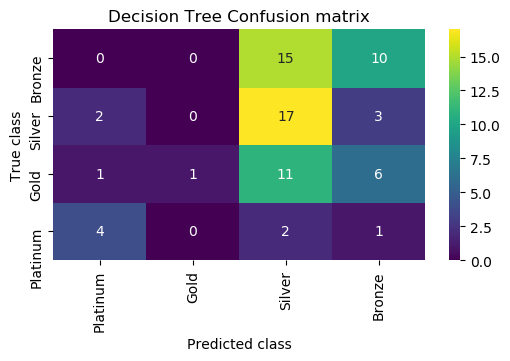

In [8]:
#function to train DecisionTreeClassifier algorithm on training data and evaluate performance on test data
dt = DecisionTreeClassifier(max_depth=3, max_features=1)
dt.fit(X_train, y_train)
#perform prediction on test data
predict = dt.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Decision Tree", predict, y_test)

SVM Accuracy  :  35.61643835616438
SVM Precision : 24.479166666666664
SVM Recall    : 28.727272727272723
SVM FScore    : 20.45143638850889


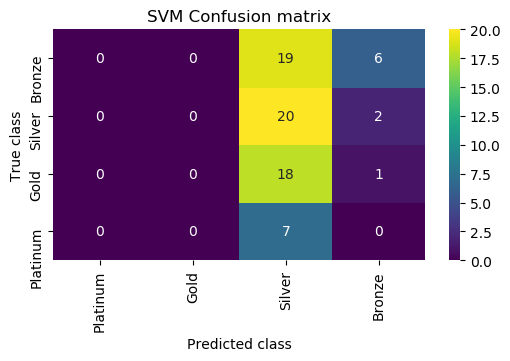

In [9]:
#function to train SVM algorithm on training data and evaluate performance on test data
svm_cls = svm.SVC(probability=True)
svm_cls.fit(X_train, y_train)
#perform prediction on test data
predict = svm_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("SVM", predict, y_test)

Logistic Regression Accuracy  :  67.12328767123287
Logistic Regression Precision : 63.83333333333333
Logistic Regression Recall    : 62.72863978127137
Logistic Regression FScore    : 62.80585356672314


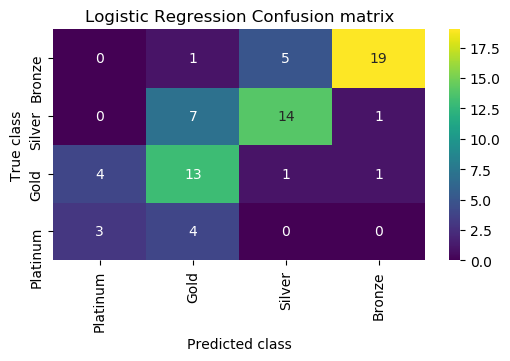

In [10]:
#function to train LogisticRegression algorithm on training data and evaluate performance on test data
lr = LogisticRegression(max_iter=1500, solver='liblinear', tol=0.2)
lr.fit(X_train, y_train)
#perform prediction on test data
predict = lr.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Logistic Regression", predict, y_test)

Random Forest Accuracy  :  50.68493150684932
Random Forest Precision : 46.13095238095239
Random Forest Recall    : 43.73923444976076
Random Forest FScore    : 38.935319767441854


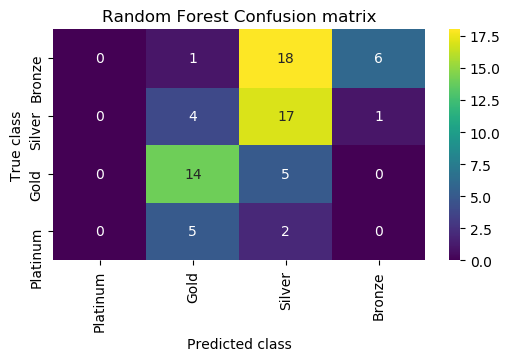

In [11]:
#function to train Random Forest algorithm on training data and evaluate performance on test data
rf = RandomForestClassifier(max_depth=1, n_estimators=10, max_features=1)
rf.fit(X_train, y_train)
#perform prediction on test data
predict = rf.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Random Forest", predict, y_test)

MLP Classifier Accuracy  :  32.87671232876712
MLP Classifier Precision : 32.74647887323944
MLP Classifier Recall    : 32.14285714285714
MLP Classifier FScore    : 22.939068100358423


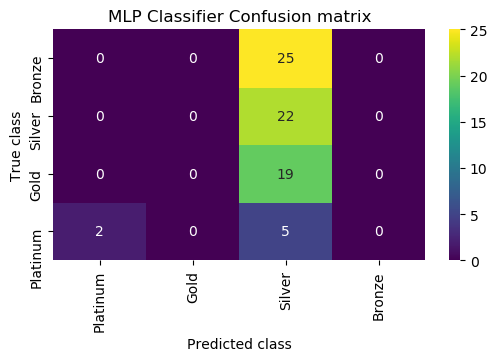

In [12]:
#function to train MLPClassifier algorithm on training data and evaluate performance on test data
mlp = MLPClassifier(solver='adam', alpha=1e-3, hidden_layer_sizes=(64, 4), random_state=1)
mlp.fit(X_train, y_train)
#perform prediction on test data
predict = mlp.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("MLP Classifier", predict, y_test)

XGBoost Accuracy  :  64.38356164383562
XGBoost Precision : 56.34822167080231
XGBoost Recall    : 53.40909090909091
XGBoost FScore    : 44.53125


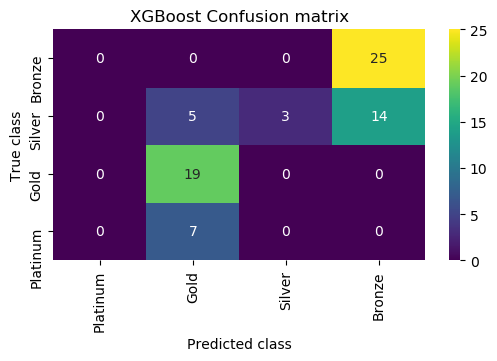

In [13]:
#function to trainXGBoost algorithm on training data and evaluate performance on test data
y_train1 = []
y_test1 = []
for i in range(len(y_train)):
    y_train1.append(y_train[i]-1)
for i in range(len(y_test)):
    y_test1.append(y_test[i]-1)    
xgb = XGBClassifier(objective='Multi:Softmax', learning_rate=10, max_depth=50, n_estimators=15, eval_metric="mlogloss", random_state=42, min_child_weight=50)
xgb.fit(X_train, y_train1)
#perform prediction on test data
predict = xgb.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("XGBoost", predict, y_test1)

In [14]:
#calculate sigma value for mahalanobis
sigma = np.cov(X.T)
sigma = np.linalg.inv(sigma)

In [15]:
#function to get absolute difference for score1
def getScoreMethod1(scores):
    absolute_difference = 0
    for i in range(len(scores)):
        for j in range(len(scores)):
            if i != j:
                absolute_difference += abs(scores[i] - scores[j])
    return absolute_difference

Propose SSL-WSC Accuracy  :  67.12328767123287
Propose SSL-WSC Precision : 69.6551724137931
Propose SSL-WSC Recall    : 62.50615174299385
Propose SSL-WSC FScore    : 64.4055944055944


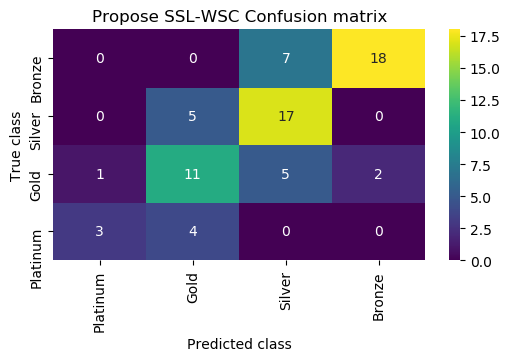

In [16]:
#run propose semi supervised algorithm
predict = []
score_list = []
for i in range(len(X_test)):#loop all unlabel test samples
    scores = [0, 0, 0, 0]
    max = 10000
    index = -1
    for j in range(len(X_train)):#loop all label training samples
        distance = mahalanobis(X_train[j], X_test[i], sigma)#calculate mahalanobis distnace and update score function
        if y_train[j] == 1:
            scores[0] = scores[0] + distance            
        if y_train[j] == 2:
            scores[1] = scores[1] + distance            
        if y_train[j] == 3:
            scores[2] = scores[2] + distance
        if y_train[j] == 4:
            scores[3] = scores[3] + distance
        if distance < max:
            max = distance
            index = y_train[j]   
    #calculate all scores and then choose min distnace and max confidence score        
    scores = np.asarray(scores)
    score_1 =  getScoreMethod1(scores)
    score_2 = np.sum(scores)
    score_3 = scores[0]
    score_4 = (score_1 + score_2) / score_3
    score_list.append([score_1, score_2, score_3, score_4])
    predict.append(index)
predict = np.asarray(predict)
#call this function to calculate accuracy and other metrics
calculateMetrics("Propose SSL-WSC", predict, y_test)

In [17]:
#displaying scores for each data point
score_list = np.asarray(score_list)
score_list = pd.DataFrame(score_list, columns=['Score1', 'Score2', 'Score3', 'Score4'])
score_list

,Score1,Score2,Score3,Score4
0,1896.402303,1186.224904,112.665009,27.360999
1,2437.871457,1887.336435,232.969564,18.565549
2,1559.215226,1279.931282,159.632847,17.785478
3,1491.598549,1165.985096,139.839977,19.004463
4,1553.110054,1235.832361,159.216970,17.516615
...,...,...,...,...
68,1859.263601,1186.734207,116.618021,26.119443
69,1294.463477,948.821018,107.351635,20.896603
70,1822.229956,1164.242093,107.815928,27.699729
71,1325.929412,975.568362,109.819443,20.957107


Learning rate set to 0.5
0:	learn: 0.6516037	total: 153ms	remaining: 613ms
1:	learn: 0.4629770	total: 172ms	remaining: 258ms
2:	learn: 0.3115132	total: 179ms	remaining: 119ms
3:	learn: 0.2081366	total: 187ms	remaining: 46.7ms
4:	learn: 0.1470661	total: 196ms	remaining: 0us
Extension CatBoost Accuracy  :  100.0
Extension CatBoost Precision : 100.0
Extension CatBoost Recall    : 100.0
Extension CatBoost FScore    : 100.0


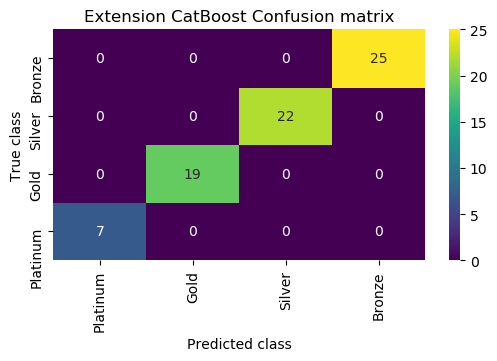

In [18]:
#run advance catboost algorithm which will train dataset using multiple iterations
#function to train CatBoost algorithm
cb = CatBoostClassifier(iterations = 5)
cb.fit(X_train, y_train)
#perform prediction on test data
predict = cb.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension CatBoost", predict, y_test)

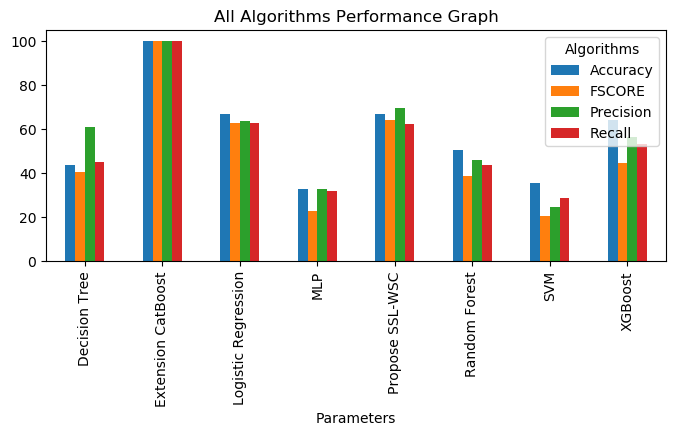

In [19]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Decision Tree','Accuracy',accuracy[0]],['Decision Tree','Precision',precision[0]],['Decision Tree','Recall',recall[0]],['Decision Tree','FSCORE',fscore[0]],
                   ['SVM','Accuracy',accuracy[1]],['SVM','Precision',precision[1]],['SVM','Recall',recall[1]],['SVM','FSCORE',fscore[1]],
                   ['Logistic Regression','Accuracy',accuracy[2]],['Logistic Regression','Precision',precision[2]],['Logistic Regression','Recall',recall[2]],['Logistic Regression','FSCORE',fscore[2]],
                   ['Random Forest','Accuracy',accuracy[3]],['Random Forest','Precision',precision[3]],['Random Forest','Recall',recall[3]],['Random Forest','FSCORE',fscore[3]],
                   ['MLP','Accuracy',accuracy[4]],['MLP','Precision',precision[4]],['MLP','Recall',recall[4]],['MLP','FSCORE',fscore[4]],
                   ['XGBoost','Accuracy',accuracy[5]],['XGBoost','Precision',precision[5]],['XGBoost','Recall',recall[5]],['XGBoost','FSCORE',fscore[5]],
                   ['Propose SSL-WSC','Accuracy',accuracy[6]],['Propose SSL-WSC','Precision',precision[6]],['Propose SSL-WSC','Recall',recall[6]],['Propose SSL-WSC','FSCORE',fscore[6]],
                   ['Extension CatBoost','Accuracy',accuracy[7]],['Extension CatBoost','Precision',precision[7]],['Extension CatBoost','Recall',recall[7]],['Extension CatBoost','FSCORE',fscore[7]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [20]:
#display all algorithm performnace
algorithms = ['Decision Tree', 'SVM', 'Logistic Regression', 'Random Forest', 'MLP', 'XGBoost', 'Propose SSL-WSC', 
              'Extension CatBoost']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Decision Tree,43.835616,61.230159,44.919686,40.583393
1,SVM,35.616438,24.479167,28.727273,20.451436
2,Logistic Regression,67.123288,63.833333,62.728640,62.805854
3,Random Forest,50.684932,46.130952,43.739234,38.935320
4,MLP,32.876712,32.746479,32.142857,22.939068
5,XGBoost,64.383562,56.348222,53.409091,44.531250
6,Propose SSL-WSC,67.123288,69.655172,62.506152,64.405594
7,Extension CatBoost,100.000000,100.000000,100.000000,100.000000


In [21]:
#read test data and predict attack
test_data = pd.read_csv("Dataset/testData.csv")#read test data
temp = test_data.values
predict = cb.predict(test_data)#perform prediction on test data using extension object
for i in range(len(predict)):
    print("Test Data = "+str(temp[i])+" Classified Service ===> "+labels[int(predict[i]-1)])
    print()

Test Data = [124.92 100.    11.9   89.    84.1   78.    82.   124.38  96.    86.  ] Classified Service ===> Platinum

Test Data = [129.34  56.     5.1   48.    74.5   78.    77.    37.69  89.    76.  ] Classified Service ===> Gold

Test Data = [958.  100.    4.8  71.   60.4  78.   84.  909.   92.   70. ] Classified Service ===> Silver

Test Data = [326.56  84.     6.2   77.    15.9   89.    89.   303.92   5.    55.  ] Classified Service ===> Bronze

Test Data = [114.  100.   27.5  50.   92.5  78.   84.  108.   64.   86. ] Classified Service ===> Platinum

Test Data = [163.8 100.   11.1  80.   62.1  78.   62.  143.2  90.   76. ] Classified Service ===> Gold



In [22]:
#=================flask code starts here
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [23]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [24]:
@app.route('/Predict', methods=['GET', 'POST'])
def predictView():
    return render_template('Predict.html', msg='')

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', msg='')

@app.route('/AdminLogin', methods=['GET', 'POST'])
def AdminLogin():
    return render_template('AdminLogin.html', msg='')

@app.route('/AdminLoginAction', methods=['GET', 'POST'])
def AdminLoginAction():
    if request.method == 'POST' and 't1' in request.form and 't2' in request.form:
        user = request.form['t1']
        password = request.form['t2']
        if user == "admin" and password == "admin":
            return render_template('AdminScreen.html', msg="Welcome "+user)
        else:
            return render_template('AdminLogin.html', msg="Invalid login details")

@app.route('/Logout')
def Logout():
    return render_template('index.html', msg='')

@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():   
    if request.method == 'POST':
        data = request.form['t1']
        test = []
        arr = data.split(",")
        for i in range(len(arr)):
            test.append(float(arr[i].strip()))
        test= np.asarray(test)    
        predict = cb.predict(test)#perform prediction on test data
        predict = int(predict[0]) - 1
        output = "Test Data = "+str(data)+" Classified Service ===> <font size=4 color=green>"+labels[predict]+"</font><br/>" 
        return render_template('Predict.html', msg=output)

In [ ]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__' (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [12/May/2026 09:54:04] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [12/May/2026 09:54:04] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [12/May/2026 09:54:08] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [12/May/2026 09:54:08] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [12/May/2026 09:54:12] "GET /AdminLogin HTTP/1.1" 200 -
127.0.0.1 - - [12/May/2026 09:54:12] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [12/May/2026 09:54:17] "POST /AdminLoginAction HTTP/1.1" 200 -
127.0.0.1 - - [12/May/2026 09:54:17] "GET /static/style.css HTTP/1.1" 304 -
